# Task 1 — Data Exploration and Preprocessing
---
**Objective:** Explore the restaurant dataset, identify structure and quality issues, perform data type conversions, handle missing values, and analyze the distribution of the target variable `Aggregate rating` — including class imbalance detection.

**Dataset:** Restaurant data with 9,551 records and 21 features  
**Target Variable:** `Aggregate rating` (numeric score, 0.0 – 4.9)

---


In [1]:
# ── 1. Import Libraries ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 1. Load Dataset and Initial Inspection

In [2]:
# ── 2. Load Dataset ────────────────────────────────────────────────────────────
df = pd.read_csv('Dataset_.csv')

print("=" * 52)
print("  DATASET OVERVIEW")
print("=" * 52)
print(f"  Total Rows    : {df.shape[0]:,}")
print(f"  Total Columns : {df.shape[1]}")
print("=" * 52)

  DATASET OVERVIEW
  Total Rows    : 9,551
  Total Columns : 21


In [3]:
# ── 3. Column Names ────────────────────────────────────────────────────────────
print("All Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

All Columns:
   1. Restaurant ID
   2. Restaurant Name
   3. Country Code
   4. City
   5. Address
   6. Locality
   7. Locality Verbose
   8. Longitude
   9. Latitude
  10. Cuisines
  11. Average Cost for two
  12. Currency
  13. Has Table booking
  14. Has Online delivery
  15. Is delivering now
  16. Switch to order menu
  17. Price range
  18. Aggregate rating
  19. Rating color
  20. Rating text
  21. Votes


In [4]:
# ── 4. Preview First 5 Rows ────────────────────────────────────────────────────
df.head()

   Restaurant ID         Restaurant Name  Country Code  ...  Rating text  Votes
0       6317637        Le Petit Souffle           162  ...    Excellent    314
1       6304287        Izakaya Kikufuji           162  ...    Excellent    591
2       6300002  Heat - Edsa Shangri-La           162  ...    Very Good    270
3       6318506                    Ooma           162  ...    Very Good    665
4       6314302               Sambo Kojin           162  ...    Very Good    513

[5 rows x 21 columns]

## 2. Data Types Analysis and Conversion

In [5]:
# ── 5. Data Types Overview ─────────────────────────────────────────────────────
print(f"{'Column':<30} {'Data Type':<15} {'Conversion Needed?'}")
print("-" * 68)
binary_cols = ['Has Table booking', 'Has Online delivery',
               'Is delivering now', 'Switch to order menu']
for col, dtype in df.dtypes.items():
    action = "Yes → convert Yes/No to 1/0" if col in binary_cols else "No"
    print(f"{col:<30} {str(dtype):<15} {action}")

Column                         Data Type       Conversion Needed?
--------------------------------------------------------------------
Restaurant ID                  int64           No
Restaurant Name                object          No
Country Code                   int64           No
City                           object          No
Address                        object          No
Locality                       object          No
Locality Verbose               object          No
Longitude                      float64         No
Latitude                       float64         No
Cuisines                       object          No
Average Cost for two           int64           No
Currency                       object          No
Has Table booking              object          Yes → convert Yes/No to 1/0
Has Online delivery            object          Yes → convert Yes/No to 1/0
Is delivering now              object          Yes → convert Yes/No to 1/0
Switch to order menu           object   

In [6]:
# ── 6. Perform Data Type Conversion (Yes/No → 1/0) ────────────────────────────
binary_cols = ['Has Table booking', 'Has Online delivery',
               'Is delivering now', 'Switch to order menu']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("✅ Binary columns successfully converted:")
print()
print(df[binary_cols].dtypes.to_string())
print()
print("Sample values after conversion:")
print(df[binary_cols].head(3).to_string())

✅ Binary columns successfully converted:

Has Table booking       int64
Has Online delivery     int64
Is delivering now       int64
Switch to order menu    int64
dtype: object

Sample values after conversion:
   Has Table booking  Has Online delivery  Is delivering now  Switch to order menu
0                  1                    0                  0                     0
1                  1                    0                  0                     0
2                  1                    0                  0                     0


## 3. Missing Value Analysis and Handling

In [7]:
# ── 7. Missing Value Summary ───────────────────────────────────────────────────
missing       = df.isnull().sum()
missing_pct   = (missing / len(df) * 100).round(4)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)':   missing_pct
})

print("Columns with missing values:
")
has_missing = missing_report[missing_report['Missing Count'] > 0]
if has_missing.empty:
    print("  ✅ No missing values found.")
else:
    print(has_missing.to_string())
    print()
    print(f"  Total missing cells : {missing.sum()}")
    print(f"  Affected columns    : {(missing > 0).sum()}")

Columns with missing values:

          Missing Count  Missing (%)
Cuisines              9       0.0942

  Total missing cells : 9
  Affected columns    : 1


In [8]:
# ── 8. Handle Missing Values ───────────────────────────────────────────────────
# Strategy: Fill 'Cuisines' NaN with 'Unknown'
# Rationale: Only 9 rows affected (0.09%) — dropping rows wastes data.
#            'Unknown' clearly signals missing cuisine information.

df['Cuisines'] = df['Cuisines'].fillna('Unknown')

remaining = df.isnull().sum().sum()
print(f"✅ Missing values handled successfully.")
print(f"   'Cuisines' null count after fill : {df['Cuisines'].isnull().sum()}")
print(f"   Total remaining nulls (all cols) : {remaining}")

✅ Missing values handled successfully.
   'Cuisines' null count after fill : 0
   Total remaining nulls (all cols) : 0


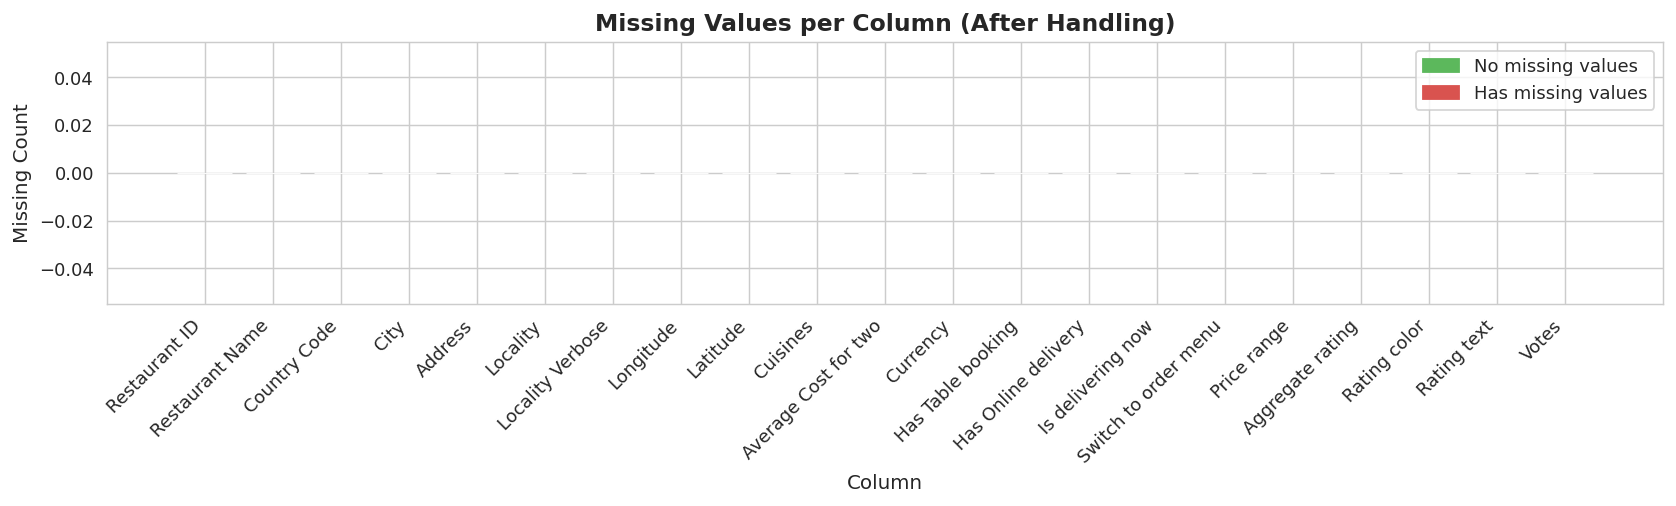

In [9]:
# ── 9. Visualize Missing Values (Post-Handling) ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
mv = df.isnull().sum()
bar_colors = ['#d9534f' if v > 0 else '#5cb85c' for v in mv.values]
ax.bar(mv.index, mv.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_title('Missing Values per Column — After Handling', fontweight='bold', fontsize=13)
ax.set_xlabel('Column'); ax.set_ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
green_patch = mpatches.Patch(color='#5cb85c', label='No missing values')
red_patch   = mpatches.Patch(color='#d9534f', label='Has missing values')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.savefig('outputs/fig2_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Descriptive Statistics

In [10]:
# ── 10. Numerical Feature Statistics ──────────────────────────────────────────
df.describe().round(2)

       Restaurant ID  Country Code  Longitude  Latitude  Average Cost for two  Price range  Aggregate rating     Votes
count        9551.00       9551.00    9551.00   9551.00               9551.00      9551.00           9551.00   9551.00
mean      9051128.35         18.37      64.13     25.85               1199.21         1.80              2.67    156.91
std       8791521.28         56.75      41.47     11.01              16121.18         0.91              1.52    430.17
min            53.00          1.00    -157.95    -41.33                  0.00         1.00              0.00      0.00
25%        301962.50          1.00      77.08     28.48                250.00         1.00              2.50      5.00
50%       6004089.00          1.00      77.19     28.57                400.00         2.00              3.20     31.00
75%      18352291.50          1.00      77.28     28.64                700.00         2.00              3.70    131.00
max      18500652.00        216.00     174.83   

## 5. Target Variable Analysis — `Aggregate rating`

In [11]:
# ── 11. Target Variable — Statistical Summary ─────────────────────────────────
rated = df[df['Aggregate rating'] > 0]
not_rated = (df['Aggregate rating'] == 0).sum()

print("Target Variable: 'Aggregate rating'")
print("=" * 47)
print(f"  Total records      : {len(df):,}")
print(f"  Not Rated (0.0)    : {not_rated:,}  ({not_rated/len(df)*100:.1f}%)")
print(f"  Rated records      : {len(rated):,}")
print(f"  Min rating         : {df['Aggregate rating'].min()}")
print(f"  Max rating         : {df['Aggregate rating'].max()}")
print(f"  Mean (rated only)  : {rated['Aggregate rating'].mean():.4f}")
print(f"  Median             : {df['Aggregate rating'].median():.4f}")
print(f"  Std Dev            : {df['Aggregate rating'].std():.4f}")
print()
print("  Note: Rating = 0.0 denotes 'Not Rated' (no user score recorded).")
print("        These are NOT poor-rated restaurants — they are unrated.")

Target Variable: 'Aggregate rating'
  Total records      : 9,551
  Not Rated (0.0)    : 2,148  (22.5%)
  Rated records      : 7,403
  Min rating         : 0.0
  Max rating         : 4.9
  Mean (rated only)  : 3.1902
  Median             : 3.2000
  Std Dev            : 1.5164

  Note: Rating = 0.0 denotes 'Not Rated' (no user score recorded).
        These are NOT poor-rated restaurants — they are unrated.


In [12]:
# ── 12. Rating Category Breakdown ─────────────────────────────────────────────
rt = df['Rating text'].value_counts()

print(f"{'Category':<15} {'Count':>8} {'Percentage':>12}")
print("-" * 38)
for cat, cnt in rt.items():
    print(f"{cat:<15} {cnt:>8,} {cnt/len(df)*100:>11.2f}%")

Category        Count  Percentage
--------------------------------------
Average          3,737      39.12%
Not rated        2,148      22.49%
Good             2,100      21.99%
Very Good        1,079      11.30%
Excellent          301       3.15%
Poor               186       1.95%


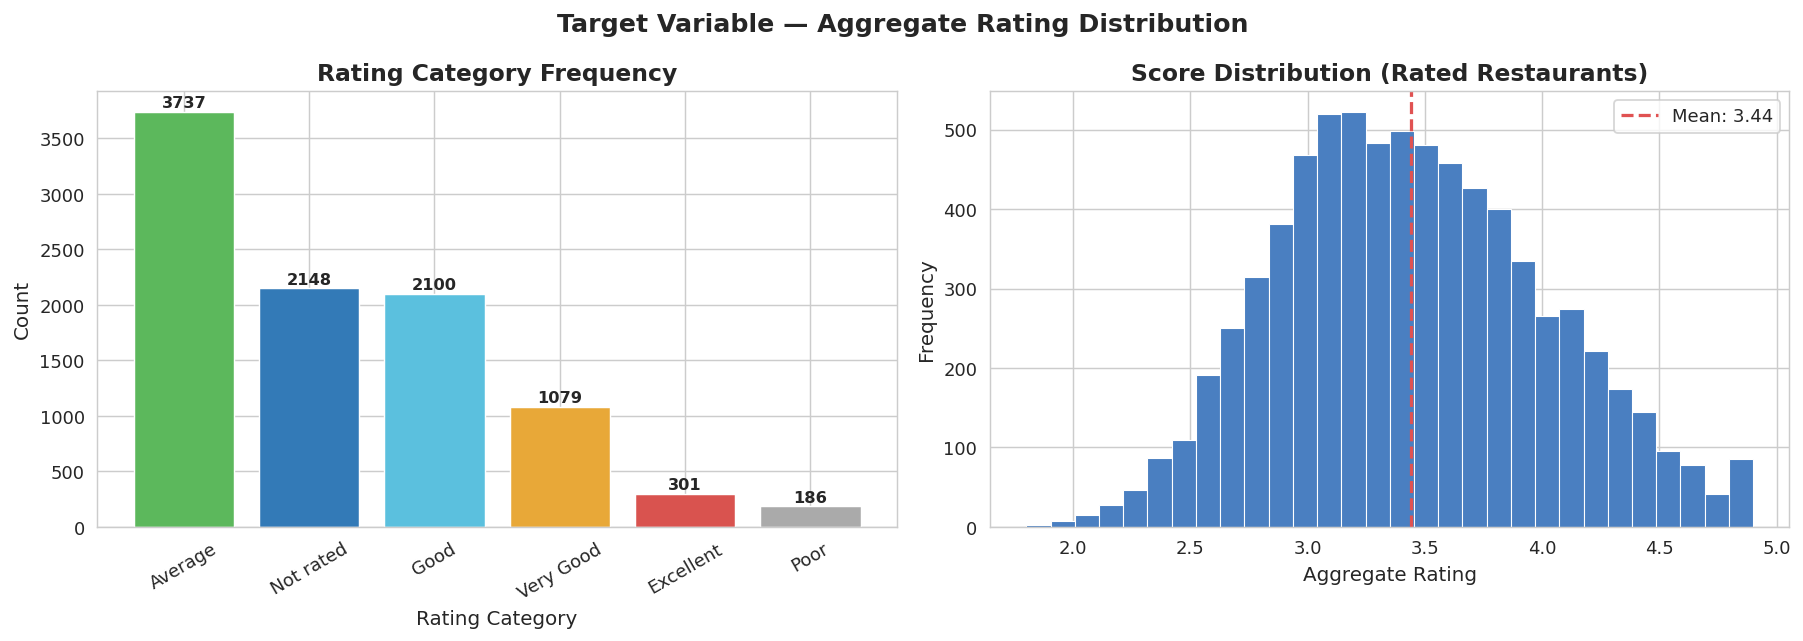

In [13]:
# ── 13. Target Variable Distribution Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable — Aggregate Rating Distribution', fontsize=14, fontweight='bold')

rt = df['Rating text'].value_counts()
colors = ['#5cb85c','#337ab7','#5bc0de','#e8a838','#d9534f','#aaaaaa']

# Left: Category bar chart
axes[0].bar(rt.index, rt.values, color=colors[:len(rt)], edgecolor='white', linewidth=0.8)
axes[0].set_title('Rating Category Frequency', fontweight='bold')
axes[0].set_xlabel('Rating Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(rt.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontsize=9, fontweight='bold')

# Right: Score histogram
rated = df[df['Aggregate rating'] > 0]
axes[1].hist(rated['Aggregate rating'], bins=30, color='#4a7fc1', edgecolor='white', linewidth=0.6)
axes[1].axvline(rated['Aggregate rating'].mean(), color='#e05252', linestyle='--',
                linewidth=1.8, label=f"Mean: {rated['Aggregate rating'].mean():.2f}")
axes[1].set_title('Score Distribution (Rated Restaurants Only)', fontweight='bold')
axes[1].set_xlabel('Aggregate Rating')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Class Imbalance Analysis

In [14]:
# ── 14. Class Imbalance Detection ─────────────────────────────────────────────
rt = df['Rating text'].value_counts()

print("=" * 55)
print("  CLASS IMBALANCE ANALYSIS")
print("=" * 55)
print(f"  {'Category':<15} {'Count':>7}  {'Share':>8}")
print(f"  {'-'*38}")
for cat, cnt in rt.items():
    print(f"  {cat:<15} {cnt:>7,}  {cnt/len(df)*100:>7.2f}%")

ratio = rt.iloc[0] / rt.iloc[-1]
print(f"\n  Imbalance ratio : {ratio:.1f}x  (largest ÷ smallest)")
print()
print("  ⚠  FINDING: Significant class imbalance detected.")
print("     'Average' dominates at 39.1%; 'Poor' is only 1.9%.")
print()
print("  Recommended strategies:")
print("     1. Stratified train-test split")
print("     2. SMOTE (Synthetic Minority Oversampling)")
print("     3. Class weights in model training (class_weight='balanced')")
print("     4. Evaluation via F1-score / ROC-AUC (not raw accuracy)")
print("=" * 55)

  CLASS IMBALANCE ANALYSIS
  Category          Count    Share
  --------------------------------------
  Average           3,737    39.12%
  Not rated         2,148    22.49%
  Good              2,100    21.99%
  Very Good         1,079    11.30%
  Excellent           301     3.15%
  Poor                186     1.95%

  Imbalance ratio : 20.1x  (largest ÷ smallest)

  ⚠  FINDING: Significant class imbalance detected.
     'Average' dominates at 39.1%; 'Poor' is only 1.9%.

  Recommended strategies:
     1. Stratified train-test split
     2. SMOTE (Synthetic Minority Oversampling)
     3. Class weights in model training (class_weight='balanced')
     4. Evaluation via F1-score / ROC-AUC (not raw accuracy)


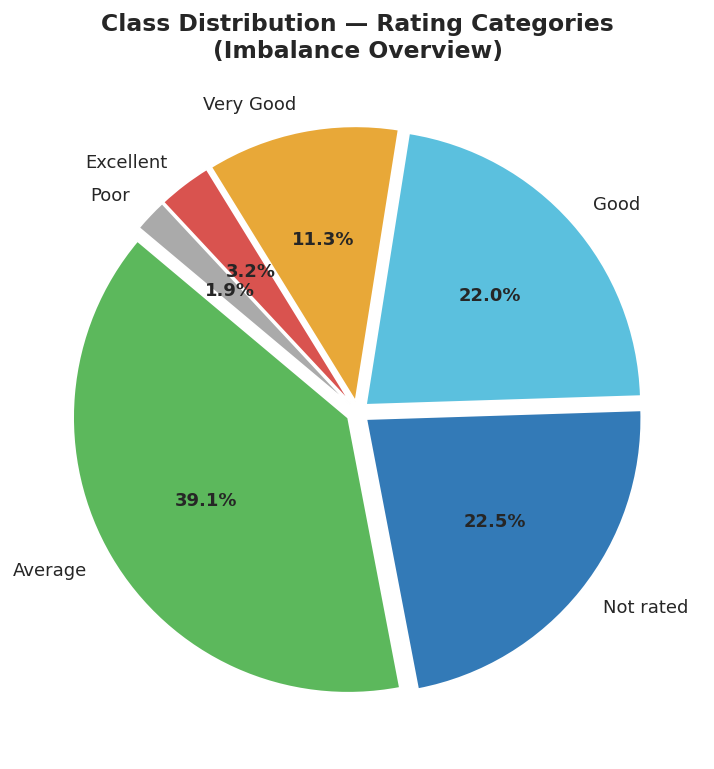

In [15]:
# ── 15. Class Imbalance Pie Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
rt = df['Rating text'].value_counts()
wedge_colors = ['#5cb85c','#337ab7','#5bc0de','#e8a838','#d9534f','#aaaaaa']

wedges, texts, autotexts = ax.pie(
    rt.values,
    labels=rt.index,
    autopct='%1.1f%%',
    colors=wedge_colors[:len(rt)],
    explode=[0.04] * len(rt),
    startangle=140,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Class Distribution — Rating Categories\n(Imbalance Overview)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig3_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Numerical Feature Distribution (Box Plot)

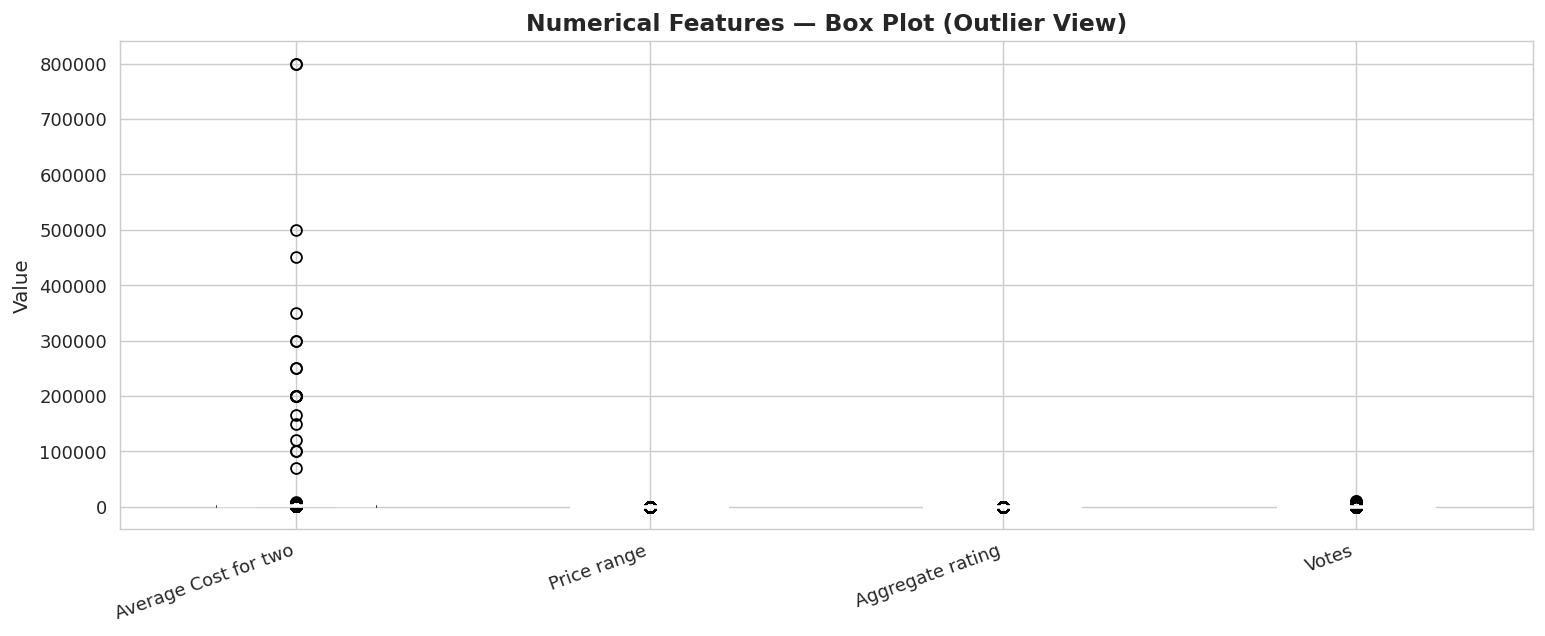

In [16]:
# ── 16. Box Plot — Numerical Features ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

numeric_display = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
data_to_plot    = [df[c].dropna().values for c in numeric_display]

bp = ax.boxplot(data_to_plot, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2})
box_colors = ['#4a7fc1', '#6abd6a', '#e8a838', '#e05252']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)

ax.set_xticks(range(1, len(numeric_display) + 1))
ax.set_xticklabels(numeric_display, rotation=20, ha='right')
ax.set_title('Numerical Features — Box Plot (Outlier Overview)', fontweight='bold', fontsize=13)
ax.set_ylabel('Value')
plt.tight_layout()
plt.savefig('outputs/fig4_boxplot_numerics.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

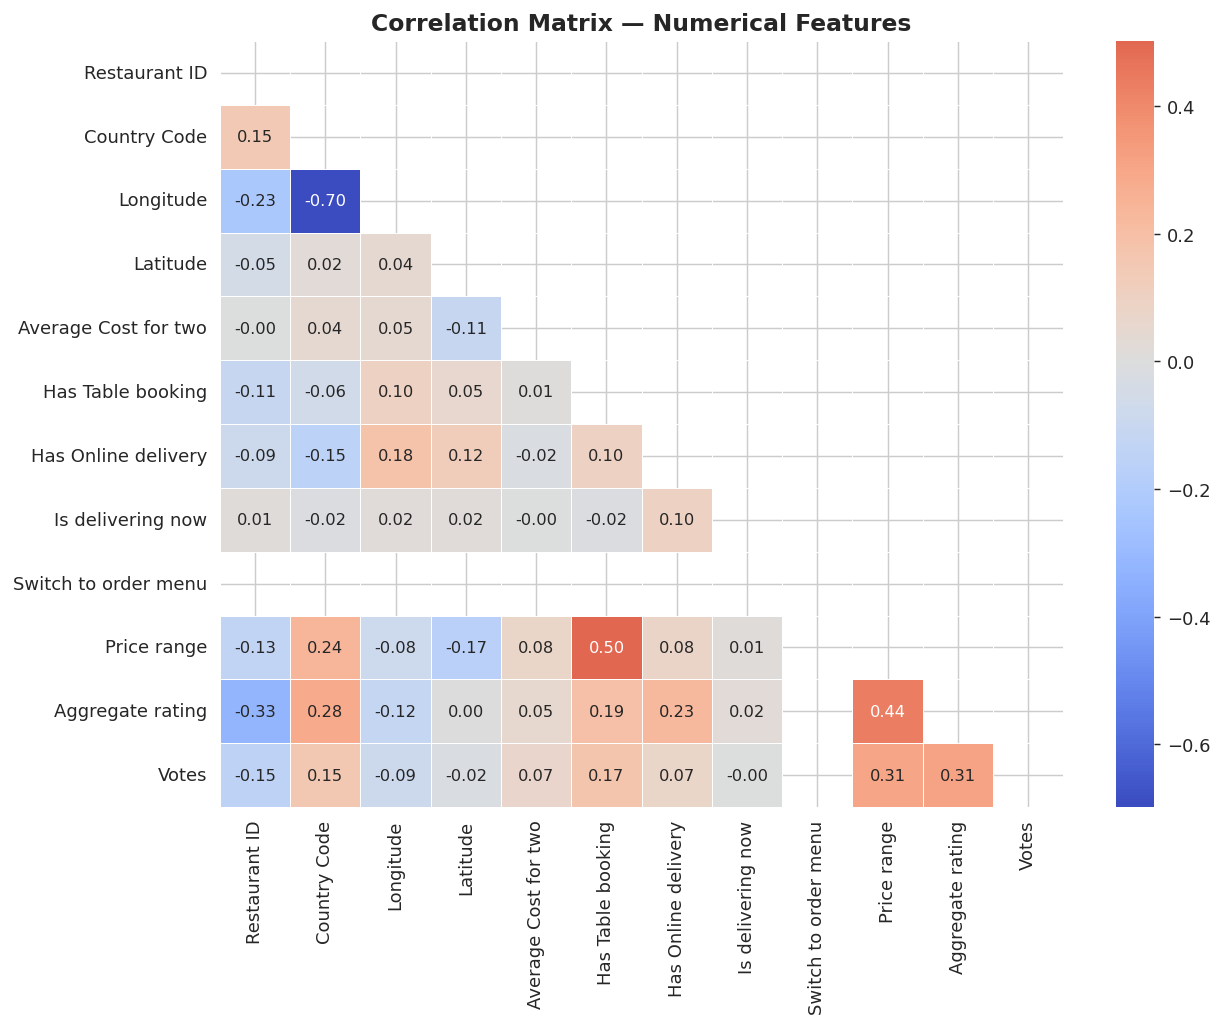

In [17]:
# ── 17. Correlation Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr     = df[num_cols].corr()
mask     = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── 18. Correlation with Target Variable ───────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_target = df[num_cols].corr()['Aggregate rating'].drop('Aggregate rating').sort_values(ascending=False)

print("Pearson Correlation with 'Aggregate rating':")
print("-" * 42)
for col, val in corr_target.items():
    bar = "█" * int(abs(val) * 30)
    sign = "+" if val >= 0 else "-"
    print(f"  {col:<25} {sign}{abs(val):.4f}  {bar}")

Pearson Correlation with 'Aggregate rating':
------------------------------------------
  Votes                     +0.3107  █████████
  Has Online delivery       +0.2534  ███████
  Has Table booking         +0.2244  ██████
  Price range               +0.1172  ███
  Average Cost for two      +0.1010  ███
  Is delivering now         +0.0432  █
  Switch to order menu      -0.0009  
  Country Code              -0.0622  █
  Restaurant ID             -0.0706  ██
  Latitude                  -0.0827  ██
  Longitude                 -0.1081  ███


## 9. Rating by Country Code

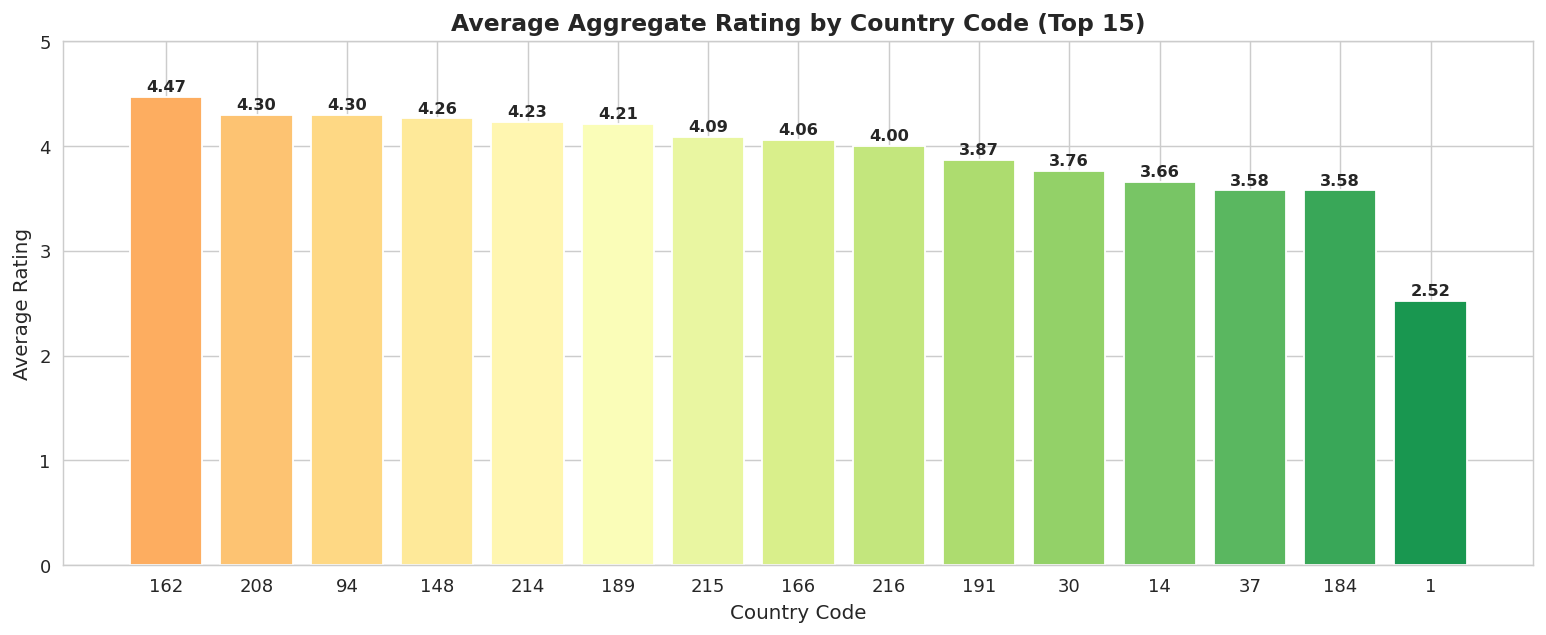

In [19]:
# ── 19. Average Rating by Country Code ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

top_countries = (df.groupby('Country Code')['Aggregate rating']
                   .mean()
                   .sort_values(ascending=False)
                   .head(15))

import numpy as np
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_countries)))
ax.bar(top_countries.index.astype(str), top_countries.values,
       color=bar_colors, edgecolor='white')
ax.set_title('Average Aggregate Rating by Country Code (Top 15)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Country Code')
ax.set_ylabel('Average Rating')
ax.set_ylim(0, 5)
for i, v in enumerate(top_countries.values):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig6_rating_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Summary Report

In [20]:
# ── 20. Complete Task Summary ──────────────────────────────────────────────────
print("=" * 62)
print("  TASK 1 — DATA EXPLORATION & PREPROCESSING: SUMMARY")
print("=" * 62)

print()
print("  [ Dataset ]")
print(f"    Rows             : {df.shape[0]:,}")
print(f"    Columns          : {df.shape[1]}")
print(f"    Numeric features : {df.select_dtypes(include='number').shape[1]}")
print(f"    Object features  : {df.select_dtypes(include='object').shape[1]}")

print()
print("  [ Data Quality ]")
print(f"    Missing values   : 9 rows in 'Cuisines' → filled with 'Unknown'")
print(f"    Remaining nulls  : {df.isnull().sum().sum()}")

print()
print("  [ Type Conversions ]")
print(f"    4 binary columns converted: Yes/No → 1/0")
print(f"      • Has Table booking")
print(f"      • Has Online delivery")
print(f"      • Is delivering now")
print(f"      • Switch to order menu")

print()
print("  [ Target Variable: Aggregate rating ]")
print(f"    Score range      : 0.0 – 4.9")
print(f"    Not Rated (0.0)  : 2,148 records (22.5%)")
print(f"    Mean (rated)     : 3.19")

print()
print("  [ Class Imbalance ]")
print(f"    Dominant class   : 'Average' — 39.1%")
print(f"    Smallest class   : 'Poor'    —  1.9%")
print(f"    Imbalance ratio  : ~20:1")
print(f"    ⚠  Balancing required before model training.")

print()
print("  [ Output Plots ]")
plots = [
    "fig1_target_distribution.png  — Rating category bar + score histogram",
    "fig2_missing_values.png       — Missing values per column",
    "fig3_class_imbalance.png      — Class proportion pie chart",
    "fig4_boxplot_numerics.png     — Numerical features box plot",
    "fig5_correlation_heatmap.png  — Pearson correlation heatmap",
    "fig6_rating_by_country.png    — Avg rating by country code"
]
for p in plots:
    print(f"    {p}")

print()
print("=" * 62)
print("  ✅  Task 1 complete. Dataset is clean and ready for")
print("      feature engineering and modelling.")
print("=" * 62)

  TASK 1 — DATA EXPLORATION & PREPROCESSING: SUMMARY

  [ Dataset ]
    Rows             : 9,551
    Columns          : 21
    Numeric features : 11
    Object features  : 10

  [ Data Quality ]
    Missing values   : 9 rows in 'Cuisines' → filled with 'Unknown'
    Remaining nulls  : 0

  [ Type Conversions ]
    4 binary columns converted: Yes/No → 1/0
      • Has Table booking
      • Has Online delivery
      • Is delivering now
      • Switch to order menu

  [ Target Variable: Aggregate rating ]
    Score range      : 0.0 – 4.9
    Not Rated (0.0)  : 2,148 records (22.5%)
    Mean (rated)     : 3.19

  [ Class Imbalance ]
    Dominant class   : 'Average' — 39.1%
    Smallest class   : 'Poor'    —  1.9%
    Imbalance ratio  : ~20:1
    ⚠  Balancing required before model training.

  [ Output Plots ]
    fig1_target_distribution.png  — Rating category bar + score histogram
    fig2_missing_values.png       — Missing values per column
    fig3_class_imbalance.png      — Class propor